In [1]:
# Libraries import 
import pandas as pd
import numpy as np

# Data load 
df = pd.read_csv('data/IPL.csv')

# Basic info 
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()


C:\Users\admin\AppData\Local\Temp\ipykernel_16324\3160171356.py:6: DtypeWarning: Columns (28,29,30,31,43,46,47,48,51) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/IPL.csv')


Shape: (278205, 64)

First 5 rows:


,Unnamed: 0,match_id,date,match_type,event_name,innings,batting_team,bowling_team,over,ball,...,team_runs,team_balls,team_wicket,new_batter,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out
0,131970,335982,18-04-2008,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,...,1,1,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
1,131971,335982,18-04-2008,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,...,1,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
2,131972,335982,18-04-2008,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
3,131973,335982,18-04-2008,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,3,0,NaN,0,2,0,"('BB McCullum', 'SC Ganguly')",NaN,False
4,131974,335982,18-04-2008,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,...,2,4,0,NaN,0,3,0,"('BB McCullum', 'SC Ganguly')",NaN,False


In [2]:
# Warning fix 
df = pd.read_csv('data/IPL.csv', low_memory=False)

In [3]:
# Unnamed column 
df = df.drop(columns=['Unnamed: 0'])


In [4]:
# Date column of proper format 
df['date'] = pd.to_datetime(df['date'])

C:\Users\admin\AppData\Local\Temp\ipykernel_16324\4257479247.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['date'] = pd.to_datetime(df['date'])


In [5]:
# Basic info
print("Shape:", df.shape)
print("\nNull values:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nSeasons available:", sorted(df['season'].unique()))
print("Total matches:", df['match_id'].nunique())
print("Total players:", df['batter'].nunique())

Shape: (278205, 63)

Null values:
extra_type          263072
wicket_kind         264382
player_out          264382
fielders            268192
runs_target         144302
review_batter       277333
team_reviewed       277333
review_decision     277333
umpire              277333
win_outcome           4702
superover_winner    274309
result_type         273503
method              274315
new_batter          264884
next_batter         264884
dtype: int64

Seasons available: ['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022', '2023', '2024', '2025']
Total matches: 1169
Total players: 703


In [6]:
# Season column clean 
df['season'] = df['season'].replace({
    '2007/08': '2008',
    '2009/10': '2010',
    '2020/21': '2021'
})

In [7]:
# Confirm 
print("Seasons cleaned:", sorted(df['season'].unique()))
print("\nData Summary:")
print(f"Total Seasons: {df['season'].nunique()}")
print(f"Total Matches: {df['match_id'].nunique()}")
print(f"Total Players: {df['batter'].nunique()}")
print(f"Total Bowlers: {df['bowler'].nunique()}")
print(f"Total Rows: {len(df)}")


Seasons cleaned: ['2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2021', '2022', '2023', '2024', '2025']

Data Summary:
Total Seasons: 17
Total Matches: 1169
Total Players: 703
Total Bowlers: 550
Total Rows: 278205


In [8]:
# BATTING ANALYSIS

# Overall Batsman Stats
batting_stats = df.groupby('batter').agg(
    total_runs=('runs_batter', 'sum'),
    balls_faced=('valid_ball', 'sum'),
    matches=('match_id', 'nunique'),
    dismissals=('player_out', 'count')
).reset_index()

In [9]:
# Strike Rate calculate 
batting_stats['strike_rate'] = round(
    (batting_stats['total_runs'] / batting_stats['balls_faced']) * 100, 2
)

# Average calculate 
batting_stats['average'] = round(
    batting_stats['total_runs'] / batting_stats['dismissals'].replace(0, 1), 2
)

# Minimum 500 balls faced (genuine batsmen filter)
batting_filtered = batting_stats[batting_stats['balls_faced'] >= 500]


In [10]:
# Top 10 by Total Runs
print("TOP 10 BATSMEN BY TOTAL RUNS:")
print(batting_filtered.nlargest(10, 'total_runs')[
    ['batter', 'total_runs', 'balls_faced', 'matches', 'strike_rate', 'average']
].to_string(index=False))

print("\n")

# Top 10 by Strike Rate
print("TOP 10 BATSMEN BY STRIKE RATE:")
print(batting_filtered.nlargest(10, 'strike_rate')[
    ['batter', 'total_runs', 'balls_faced', 'matches', 'strike_rate', 'average']
].to_string(index=False))

TOP 10 BATSMEN BY TOTAL RUNS:
        batter  total_runs  balls_faced  matches  strike_rate  average
       V Kohli        8671         6505      259       133.30    37.54
     RG Sharma        7048         5317      266       132.56    28.65
      S Dhawan        6769         5304      221       127.62    34.89
     DA Warner        6567         4680      184       140.32    40.04
      SK Raina        5536         4025      200       137.54    32.95
      MS Dhoni        5439         3935      241       138.22    34.42
      KL Rahul        5235         3836      135       136.47    45.52
AB de Villiers        5181         3400      170       152.38    41.45
     AM Rahane        5032         4021      183       125.14    30.13
      CH Gayle        4997         3331      141       150.02    39.04


TOP 10 BATSMEN BY STRIKE RATE:
         batter  total_runs  balls_faced  matches  strike_rate  average
        PD Salt        1056          595       34       177.48    33.00
     AD Russ

In [11]:
# BOWLING ANALYSIS

# Overall Bowler Stats
bowling_stats = df.groupby('bowler').agg(
    runs_given=('runs_bowler', 'sum'),
    balls_bowled=('valid_ball', 'sum'),
    wickets=('bowler_wicket', 'sum'),
    matches=('match_id', 'nunique')
).reset_index()


In [12]:
# Economy Rate calculate karo (runs per over)
bowling_stats['economy'] = round(
    (bowling_stats['runs_given'] / bowling_stats['balls_bowled']) * 6, 2
)

# Strike Rate calculate karo (balls per wicket)
bowling_stats['bowling_sr'] = round(
    bowling_stats['balls_bowled'] / bowling_stats['wickets'].replace(0, 1), 2
)

# Average calculate karo (runs per wicket)
bowling_stats['bowling_avg'] = round(
    bowling_stats['runs_given'] / bowling_stats['wickets'].replace(0, 1), 2
)

# Minimum 300 balls bowled filter
bowling_filtered = bowling_stats[bowling_stats['balls_bowled'] >= 300]

In [13]:
# Top 10 by Wickets
print("TOP 10 BOWLERS BY WICKETS:")
print(bowling_filtered.nlargest(10, 'wickets')[
    ['bowler', 'wickets', 'matches', 'economy', 'bowling_avg', 'bowling_sr']
].to_string(index=False))

print("\n")

# Top 10 by Economy (best economy = low runs diye)
print("TOP 10 BOWLERS BY ECONOMY RATE:")
print(bowling_filtered.nsmallest(10, 'economy')[
    ['bowler', 'wickets', 'matches', 'economy', 'bowling_avg', 'bowling_sr']
].to_string(index=False))

TOP 10 BOWLERS BY WICKETS:
    bowler  wickets  matches  economy  bowling_avg  bowling_sr
 YS Chahal      221      172     7.96        22.77       17.15
   B Kumar      198      190     7.69        27.33       21.32
 PP Chawla      192      191     7.96        26.60       20.05
 SP Narine      192      187     6.80        25.69       22.66
  R Ashwin      187      217     7.20        30.22       25.19
 JJ Bumrah      186      145     7.25        21.82       18.06
  DJ Bravo      183      158     8.38        23.83       17.05
  A Mishra      174      162     7.38        23.82       19.37
 RA Jadeja      170      225     7.67        30.52       23.86
SL Malinga      170      122     7.14        19.80       16.63


TOP 10 BOWLERS BY ECONOMY RATE:
          bowler  wickets  matches  economy  bowling_avg  bowling_sr
        A Kumble       45       42     6.58        23.51       21.44
      GD McGrath       12       14     6.61        29.75       27.00
  M Muralitharan       64       66     

In [14]:
# SQL ANALYSIS — SQLite use karenge

import sqlite3


In [15]:
# Database banao
conn = sqlite3.connect('ipl_database.db')

# Data SQLite mein daalo
df.to_sql('ipl', conn, if_exists='replace', index=False)
batting_stats.to_sql('batting', conn, if_exists='replace', index=False)
bowling_stats.to_sql('bowling', conn, if_exists='replace', index=False)

print("Database ready!")

Database ready!


In [16]:
# --- Query 1: Top 10 Batsmen by Runs ---
query1 = """
SELECT batter, total_runs, balls_faced, matches, strike_rate, average
FROM batting
WHERE balls_faced >= 500
ORDER BY total_runs DESC
LIMIT 10;
"""

In [17]:
# --- Query 2: Best Economy Bowlers ---
query2 = """
SELECT bowler, wickets, matches, economy, bowling_avg
FROM bowling
WHERE balls_bowled >= 300
ORDER BY economy ASC
LIMIT 10;
"""


In [18]:
# --- Query 3: Season wise runs ---
query3 = """
SELECT season, 
       SUM(runs_batter) as total_runs,
       COUNT(DISTINCT match_id) as matches,
       COUNT(DISTINCT batter) as unique_batters
FROM ipl
GROUP BY season
ORDER BY season;
"""

In [19]:
# --- Query 4: Best Death Over Bowlers (over 16-20) ---
query4 = """
SELECT bowler,
       SUM(runs_bowler) as runs_given,
       SUM(valid_ball) as balls_bowled,
       SUM(bowler_wicket) as wickets,
       ROUND(SUM(runs_bowler) * 6.0 / SUM(valid_ball), 2) as death_economy
FROM ipl
WHERE over >= 16
GROUP BY bowler
HAVING balls_bowled >= 120
ORDER BY death_economy ASC
LIMIT 10;
"""

In [20]:
# Results print 
print("\n TOP 10 BATSMEN BY RUNS:")
print(pd.read_sql(query1, conn).to_string(index=False))

print("\n BEST ECONOMY BOWLERS:")
print(pd.read_sql(query2, conn).to_string(index=False))

print("\n SEASON WISE RUNS:")
print(pd.read_sql(query3, conn).to_string(index=False))

print("\n BEST DEATH OVER BOWLERS:")
print(pd.read_sql(query4, conn).to_string(index=False))


 TOP 10 BATSMEN BY RUNS:
        batter  total_runs  balls_faced  matches  strike_rate  average
       V Kohli        8671         6505      259       133.30    37.54
     RG Sharma        7048         5317      266       132.56    28.65
      S Dhawan        6769         5304      221       127.62    34.89
     DA Warner        6567         4680      184       140.32    40.04
      SK Raina        5536         4025      200       137.54    32.95
      MS Dhoni        5439         3935      241       138.22    34.42
      KL Rahul        5235         3836      135       136.47    45.52
AB de Villiers        5181         3400      170       152.38    41.45
     AM Rahane        5032         4021      183       125.14    30.13
      CH Gayle        4997         3331      141       150.02    39.04

 BEST ECONOMY BOWLERS:
          bowler  wickets  matches  economy  bowling_avg
        A Kumble       45       42     6.58        23.51
      GD McGrath       12       14     6.61        29.7

In [21]:
# VISUALIZATION

import matplotlib.pyplot as plt
import seaborn as sns

# Style set karo
plt.style.use('dark_background')
sns.set_palette("husl")


In [22]:
import os

# Charts folder automatically banao
os.makedirs('charts', exist_ok=True)
print("Charts folder ready!")

Charts folder ready!


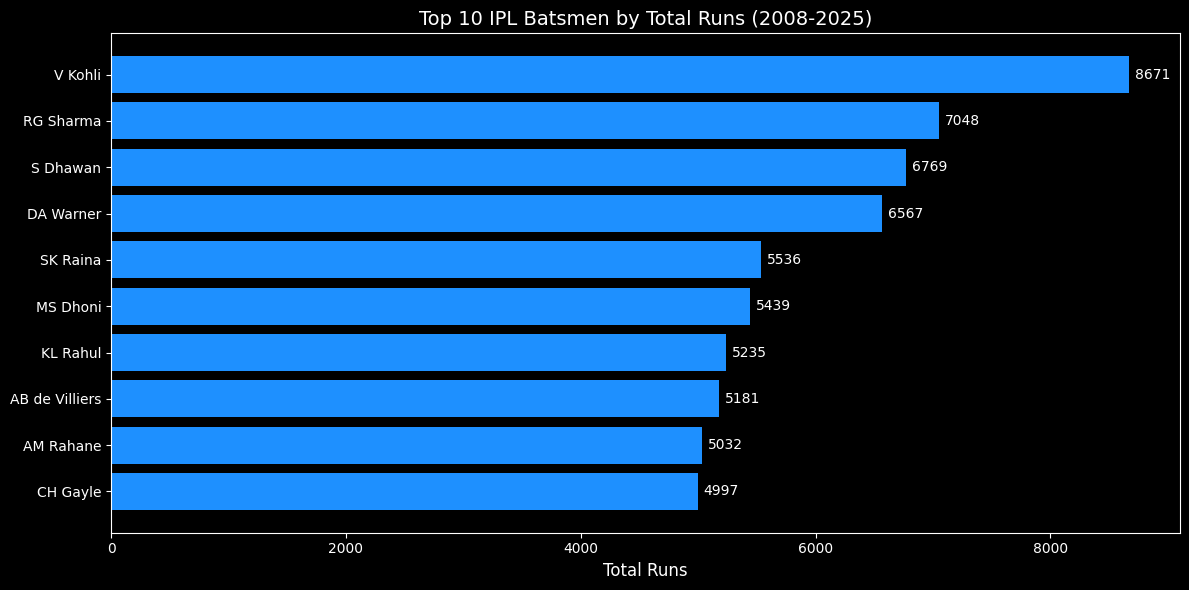

In [23]:
# --- Chart 1: Top 10 Batsmen by Runs ---
top_batsmen = batting_filtered.nlargest(10, 'total_runs')

plt.figure(figsize=(12, 6))
bars = plt.barh(top_batsmen['batter'], top_batsmen['total_runs'], color='dodgerblue')
plt.xlabel('Total Runs', fontsize=12)
plt.title('Top 10 IPL Batsmen by Total Runs (2008-2025)', fontsize=14)
plt.gca().invert_yaxis()
for bar, val in zip(bars, top_batsmen['total_runs']):
    plt.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=10)
plt.tight_layout()
plt.savefig('charts/top_batsmen.png', dpi=150)
plt.show()

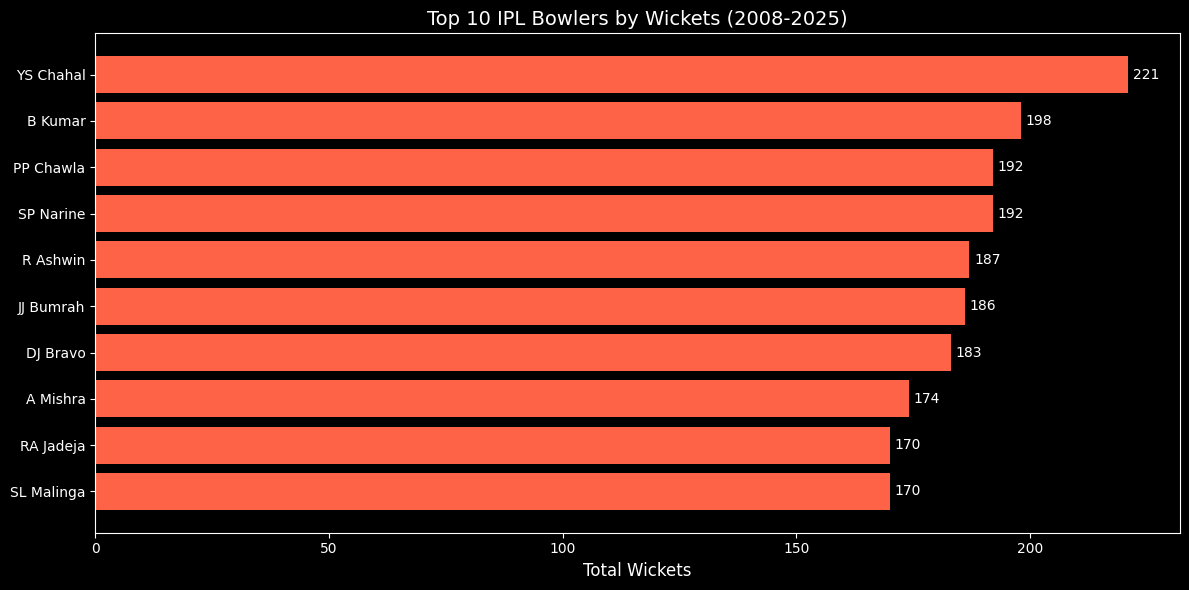

In [24]:
# --- Chart 2: Top 10 Bowlers by Wickets ---
top_bowlers = bowling_filtered.nlargest(10, 'wickets')

plt.figure(figsize=(12, 6))
bars = plt.barh(top_bowlers['bowler'], top_bowlers['wickets'], color='tomato')
plt.xlabel('Total Wickets', fontsize=12)
plt.title('Top 10 IPL Bowlers by Wickets (2008-2025)', fontsize=14)
plt.gca().invert_yaxis()
for bar, val in zip(bars, top_bowlers['wickets']):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             str(int(val)), va='center', fontsize=10)
plt.tight_layout()
plt.savefig('charts/top_bowlers.png', dpi=150)
plt.show()

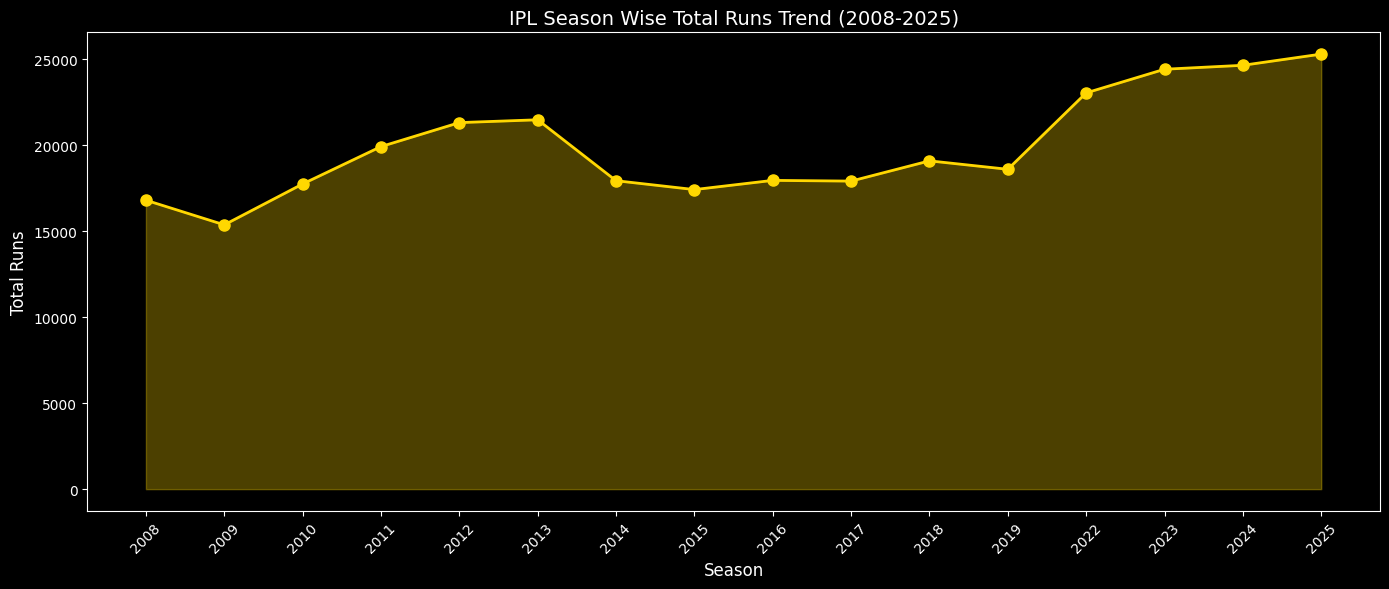

In [25]:
# --- Chart 3: Season Wise Runs ---
season_data = pd.read_sql(query3, conn)
season_data = season_data[season_data['season'] != '2021']

plt.figure(figsize=(14, 6))
plt.plot(season_data['season'], season_data['total_runs'],
         marker='o', color='gold', linewidth=2, markersize=8)
plt.fill_between(season_data['season'], season_data['total_runs'],
                 alpha=0.3, color='gold')
plt.xlabel('Season', fontsize=12)
plt.ylabel('Total Runs', fontsize=12)
plt.title('IPL Season Wise Total Runs Trend (2008-2025)', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('charts/season_runs.png', dpi=150)
plt.show()

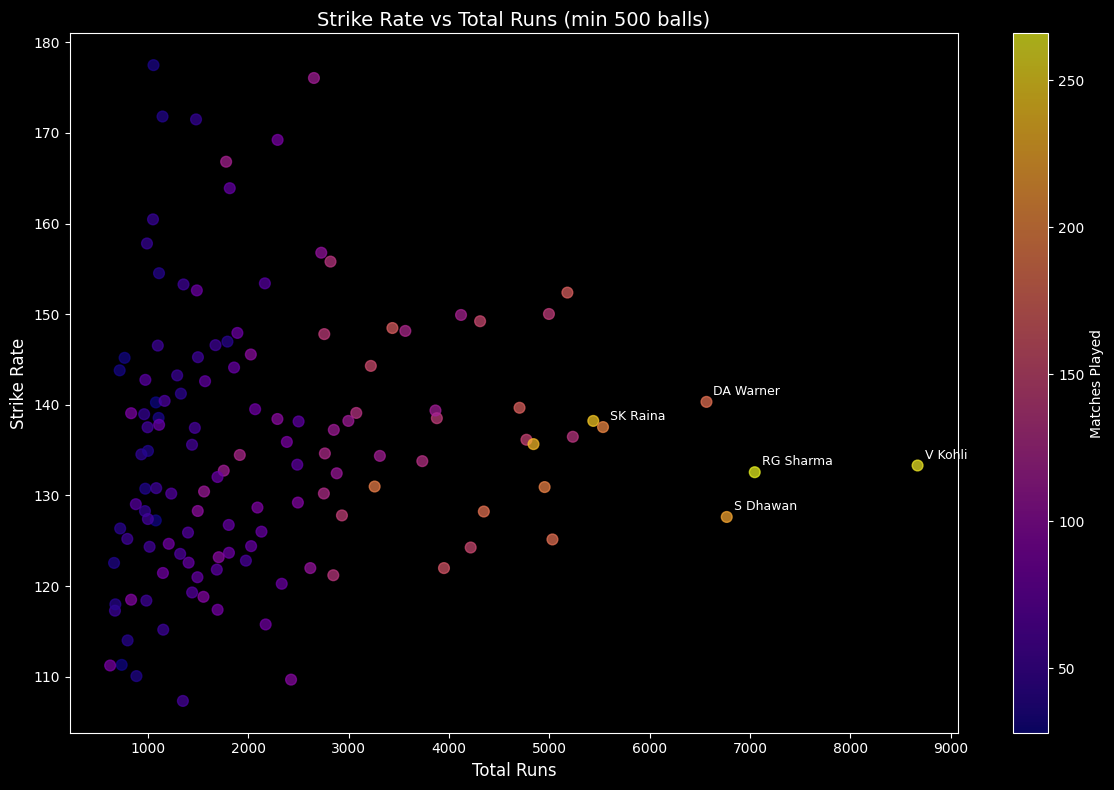

save all chart


In [26]:
# --- Chart 4: Strike Rate vs Runs (Scatter) ---
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    batting_filtered['total_runs'],
    batting_filtered['strike_rate'],
    c=batting_filtered['matches'],
    cmap='plasma',
    alpha=0.7,
    s=60
)
plt.colorbar(scatter, label='Matches Played')
plt.xlabel('Total Runs', fontsize=12)
plt.ylabel('Strike Rate', fontsize=12)
plt.title('Strike Rate vs Total Runs (min 500 balls)', fontsize=14)

top_players = batting_filtered.nlargest(5, 'total_runs')
for _, row in top_players.iterrows():
    plt.annotate(row['batter'],
                (row['total_runs'], row['strike_rate']),
                textcoords="offset points",
                xytext=(5, 5), fontsize=9, color='white')
plt.tight_layout()
plt.savefig('charts/scatter.png', dpi=150)
plt.show()

print("save all chart")

In [27]:
# CSV EXPORT FOR TABLEAU

# Batting stats export
batting_filtered.to_csv('charts/batting_stats.csv', index=False)

# Bowling stats export
bowling_filtered.to_csv('charts/bowling_stats.csv', index=False)

# Season wise data export
season_data.to_csv('charts/season_data.csv', index=False)

# Death over bowlers export
death_bowlers = pd.read_sql(query4, conn)
death_bowlers.to_csv('charts/death_bowlers.csv', index=False)

print("ALL CSV files export !")
print("\nFiles created:")
print("  charts/batting_stats.csv")
print("  charts/bowling_stats.csv")
print("  charts/season_data.csv")
print("  charts/death_bowlers.csv")

ALL CSV files export !

Files created:
  charts/batting_stats.csv
  charts/bowling_stats.csv
  charts/season_data.csv
  charts/death_bowlers.csv


In [28]:
# Season_data ko fix 
season_data['season'] = season_data['season'].astype(str)

# export 
season_data.to_csv('charts/season_data.csv', index=False)

print("Fixed! Season ab string hai")
print(season_data.dtypes)
print(season_data.head())

Fixed! Season ab string hai
season            object
total_runs         int64
matches            int64
unique_batters     int64
dtype: object
  season  total_runs  matches  unique_batters
0   2008       16809       58             154
1   2009       15376       57             150
2   2010       17754       60             164
3   2011       19928       73             180
4   2012       21323       74             170
